In [ ]:
# Photopeak analysis
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import pandas as pd
from matplotlib import patches
import random
from scipy.optimize import curve_fit
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
indices = {
      0 : (4,7-7),
      1 : (4,7-6),
      2 : (7,7-5),
      3 : (5,7-7),
      4 : (5,7-4),
      5 : (5,7-5),
      6 : (4,7-4),
      7 : (7,7-7),
      8 : (6,7-6),
      9 : (7,7-4),
      10 : (5,7-6),
      11 : (6,7-4),
      12 : (4,7-5),
      13 : (6,7-5),
      14 : (6,7-7),
      15 : (7,7-6),
      16 : (3,7-7),
      17 : (3,7-6),
      18 : (2,7-7),
      19 : (2,7-6),
      20 : (0,7-7),
      21 : (1,7-7),
      22 : (0,7-6),
      23 : (1,7-6),
      24 : (3,7-5),
      25 : (1,7-5),
      26 : (2,7-5),
      27 : (4,7-3),
      28 : (0,7-5),
      29 : (3,7-4),
      30 : (0,7-4),
      31 : (1,7-4),
      32 : (2,7-4),
      33 : (3,7-3),
      34 : (2,7-3),
      35 : (0,7-3),
      36 : (1,7-3),
      37 : (0,7-2),
      38 : (5,7-3),
      39 : (1,7-2),
      40 : (2,7-2),
      41 : (3,7-2),
      42 : (1,7-1),
      43 : (0,7-1),
      44 : (0,7-0),
      45 : (3,7-1),
      46 : (1,7-0),
      47 : (2,7-1),
      48 : (3,7-0),
      49 : (2,7-0),
      50 : (6,7-2),
      51 : (6,7-1),
      52 : (7,7-1),
      53 : (4,7-1),
      54 : (5,7-1),
      55 : (6,7-0),
      56 : (7,7-0),
      57 : (7,7-2),
      58 : (7,7-3),
      59 : (4,7-2),
      60 : (5,7-0),
      61 : (5,7-2),
      62 : (6,7-3),
      63 : (4,7-0),
      64:(3+8,7),
      65:(3+8,6),
      66:(2+8,4),
      67:(2+8,6),
      68:(3+8,4),
      69:(1+8,7),
      70:(1+8,5),
      71:(0+8,7),
      72:(1+8,6),
      73:(3+8,3),
      74:(2+8,7),
      75:(2+8,3),
      76:(3+8,5),
      77:(0+8,5),
      78:(2+8,5),
      79:(0+8,6),
      80:(4+8,7),
      81:(6+8,7),
      82:(5+8,7),
      83:(7+8,7),
      84:(5+8,6),
      85:(4+8,6),
      86:(6+8,6),
      87:(7+8,6),
      88:(4+8,5),
      89:(6+8,5),
      90:(5+8,5),
      91:(1+8,4),
      92:(7+8,5),
      93:(7+8,4),
      94:(6+8,4),
      95:(4+8,4),
      96:(5+8,4),
      97:(5+8,3),
      98:(6+8,3),
      99:(4+8,3),
      100:(7+8,3),
      101:(7+8,2),
      102:(0+8,4),
      103:(6+8,2),
      104:(7+8,1),
      105:(5+8,2),
      106:(6+8,1),
      107:(4+8,2),
      108:(7+8,0),
      109:(5+8,1),
      110:(6+8,0),
      111:(4+8,1),
      112:(5+8,0),
      113:(4+8,0),
      114:(0+8,2),
      115:(2+8,1),
      116:(0+8,1),
      117:(3+8,1),
      118:(1+8,1),
      119:(1+8,0),
      120:(0+8,0),
      121:(1+8,2),
      122:(1+8,3),
      123:(3+8,2),
      124:(2+8,0),
      125:(2+8,2),
      126:(0+8,3),
      127:(3+8,0)}

index_pairs = []
for i in range(64, 128):
    coord = indices[i]
    # find the dictionary key with value (coord[0], 7-coord[1])
    other = next(k for k, v in indices.items() if v == (coord[0], 7-coord[1]))
    index_pairs.append((i, other))

print(index_pairs)

def get_compliment(index):
    # Get the second index of the pair with the given index as the first index
    return next(pair[1] for pair in index_pairs if pair[0] == index)

def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))

# Function for finding photopeak, modified from ChannelPairBuilder.py
def findPhotopeak(hist, bins):
    photopeak = 0
    for i in range(1, len(hist)-4):
        #if hist[-1*i] > hist[-1*(i+1)] and hist[-1*i] > hist[-1*(i+2)] and hist[-1*i] >= 0.5 * np.max(hist):
        if hist[-1*i] >= 0.5 * np.max(hist):
            photopeak = len(hist)-1*i
            break
    fit_p = [0,1,1]
    fit_x = list(bins[photopeak-5:photopeak+5])
    fit_y = list(hist[photopeak-5:photopeak+5])

    if len(fit_x) != 0 and len(fit_y) != 0:
        try:
            fit_p, _ = curve_fit(gaussian, fit_x, fit_y, p0=[max(fit_y)*0.8, bins[photopeak], 2])
        except:
            print(f'Photopeak fit failed {id}')
    return fit_p

[(64, 127), (65, 117), (66, 75), (67, 115), (68, 73), (69, 119), (70, 121), (71, 120), (72, 118), (73, 68), (74, 124), (75, 66), (76, 123), (77, 114), (78, 125), (79, 116), (80, 113), (81, 110), (82, 112), (83, 108), (84, 109), (85, 111), (86, 106), (87, 104), (88, 107), (89, 103), (90, 105), (91, 122), (92, 101), (93, 100), (94, 98), (95, 99), (96, 97), (97, 96), (98, 94), (99, 95), (100, 93), (101, 92), (102, 126), (103, 89), (104, 87), (105, 90), (106, 86), (107, 88), (108, 83), (109, 84), (110, 81), (111, 85), (112, 82), (113, 80), (114, 77), (115, 67), (116, 79), (117, 65), (118, 72), (119, 69), (120, 71), (121, 70), (122, 91), (123, 76), (124, 74), (125, 78), (126, 102), (127, 64)]


Text(0.5, 1.0, '28um position, view on F1')

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


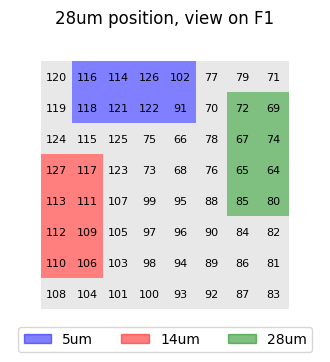

In [2]:
crystal_indices = [72, 69, 67, 74, 65, 64, 85, 80]
crystal_indices_down = [86, 87, 89, 92, 94, 93,98, 100]
crystal_indices_left = [106, 110, 109, 112, 111, 113, 117, 127]
crystal_indices_up = [118, 116, 121, 114, 122, 126, 91, 102]

#crystal_indices_list = [crystal_indices_down, crystal_indices, crystal_indices_left] # 14um pos
crystal_indices_list = [crystal_indices_up, crystal_indices_left, crystal_indices] # 28um pos
#crystal_indices_list = [crystal_indices, crystal_indices_up, crystal_indices_down] # 05m pos
colorlist = ['blue', 'red', 'green', 'lightgray']
def get_color(val):
    if val in crystal_indices_list[0]:
        return colorlist[0]
    elif val in crystal_indices_list[1]:
        return colorlist[1]
    elif val in crystal_indices_list[2]:
        return colorlist[2]
    else:
        return colorlist[3]
plt.figure(figsize = (4, 4))
ax = plt.gca()
for n in range(64, 128):
    # Use the indices dictionary to get positions
    if n in indices:
        y, x = indices[n]
        y = 15 - y
        if y >= 8:
            y += 0.4
        rect = patches.Rectangle((x, y), 1, 1, linewidth=0, facecolor=get_color(n), alpha=0.5)
        ax.add_patch(rect)
        ax.text(x + 0.5, y + 0.5, str(n), fontsize=8, ha='center', va='center')
    else:
        continue

ax.tick_params(axis='both', which='both', bottom=False, top=False,
                left=False, right=False, labelbottom=False, labelleft=False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.axis('equal')
ax.set_ylim(-1, 9)
ax.set_xlim(-1, 9)
import matplotlib.patches as mpatches

# Custom legend handles for the four position groups (matching colorlist indices)
legend_handles = [
    mpatches.Patch(color=colorlist[0], label='5um', alpha=0.5),
    mpatches.Patch(color=colorlist[1], label='14um', alpha=0.5),
    mpatches.Patch(color=colorlist[2], label='28um', alpha=0.5)
]
ax.legend(
    handles=legend_handles, 
    loc='center', 
    frameon=True, 
    ncol=3, # Make the legend horizontal by using 3 columns
    bbox_to_anchor=(0.5, 0.0) # Position the legend above the plot
)

ax.set_title('28um position, view on F1')

In [16]:
# Read in data
paths = [
    #'f15mm.dat',
    #'HighInt Data/14um15mm.dat',
    'HighInt Data/14um15mmOV275.dat',
    'HighInt Data/14um28mmOV275.dat',
    'HighInt Data/14um02mm.dat',
    'HighInt Data/14um05mm.dat',
    'HighInt Data/14um10mm.dat',
    'HighInt Data/14um20mm.dat',
    'HighInt Data/14um25mm.dat',
    'HighInt Data/14um28mm.dat',
]
doi_data = []
names = ['0mm', '+13mm', '-10mm', '-5mm', '5mm', '10mm', '13mm']
distances = [0, 13, -10, -5, 5, 10, 13]
for path in paths:
    df = pd.read_csv(path, sep = '\t', header=None)
    print(df.shape)
    df = df.iloc[:, [3, 4, 8, 9, 13, 14]]
    data = np.asarray(df, dtype = np.float32)
    data = data[(data[:, 1] >= 768) & (data[:, 1] < 896)]
    print(data)
    doi_data.append(data)
filtered_doi_data = doi_data

(125568, 15)
[[ 18.221645 873.        11.500706 454.         9.838875 121.      ]
 [  6.073719 889.        13.623749 497.        13.130512  80.      ]
 [ 11.306221 808.         8.059471 500.         6.563526  79.      ]
 ...
 [ 17.29063  850.         7.878216 492.         8.560448  83.      ]
 [  7.951508 825.         8.286041 455.         8.010086 120.      ]
 [ 16.947823 893.        17.42472  495.        16.371685  85.      ]]
(120410, 15)
[[ 14.238865 853.         2.053852 511.         2.108418  64.      ]
 [ 14.53944  869.         8.751507 489.         8.751514  90.      ]
 [ 13.614605 810.        13.892155 454.        14.07724  121.      ]
 ...
 [ 17.592087 772.         5.245941 471.         6.118114 104.      ]
 [ 12.520237 861.        13.375816 491.        13.831081  88.      ]
 [ 10.712765 780.        10.106403 470.        15.281704 106.      ]]
(120045, 15)
[[ 21.315712 828.        25.586147 485.        22.864265  92.      ]
 [ 22.772678 889.        11.849949 470.        15.10

In [4]:
# Filter each dataset in doi_data for columns with highest activity in opposite module, "digital collimator"
digitalcollimate = True
photopeakcuts = False

module_ids = [k for k, v in indices.items() if v[1] == 2]
filtered_doi_data = []
photopeakbounds = pd.read_csv('refphotopeakbounds.txt', sep = '\t', header=None)
photopeakbounds = photopeakbounds.to_numpy()
print(photopeakbounds[0:5])
for dat in doi_data:
    if photopeakcuts and digitalcollimate:
        ids = np.asarray(dat[:, 1] - 768, dtype=np.int32)
        mask = (dat[:, 0] > photopeakbounds[ids, 0]) & (dat[:, 0] < photopeakbounds[ids, 1])
        filtered_data = dat[mask]
        filtered_data = filtered_data[np.isin(filtered_data[:, 1] - 768, module_ids)]
    elif photopeakcuts:
        ids = np.asarray(dat[:, 1] - 768, dtype=np.int32)
        mask = (dat[:, 0] > photopeakbounds[ids, 0]) & (dat[:, 0] < photopeakbounds[ids, 1])
        filtered_data = dat[mask]
    elif digitalcollimate:
        filtered_data = dat[np.isin(dat[:, 1] - 768, module_ids)]
    else: 
        filtered_data = dat
    filtered_doi_data.append(filtered_data)
    print(f"Original: {len(dat)}, Filtered: {len(filtered_data)}")

[[26.00248695 29.87660952]
 [26.43956976 29.67640131]
 [25.75113206 29.69455349]
 [24.92595947 28.7331617 ]
 [27.17888032 30.9681396 ]]
Original: 110324, Filtered: 49718
Original: 118901, Filtered: 53498
Original: 116531, Filtered: 55132
Original: 115438, Filtered: 55797
Original: 121797, Filtered: 58287
Original: 119258, Filtered: 57451
Original: 117094, Filtered: 56061
Original: 115360, Filtered: 55189


In [17]:
# Statistics to keep for later fitting
photopeaksinit0keep = []
photopeaksinit3keep = []
photopeakshifts0keep = []
photopeakshifts3keep = []

In [254]:
photopeaksinit0keep = photopeaksinit0keep[:-1]
photopeaksinit3keep = photopeaksinit3keep[:-1]
photopeakshifts0keep = photopeakshifts0keep[:-1]
photopeakshifts3keep = photopeakshifts3keep[:-1]

In [255]:
len(photopeaksinit0keep)

2

0 13


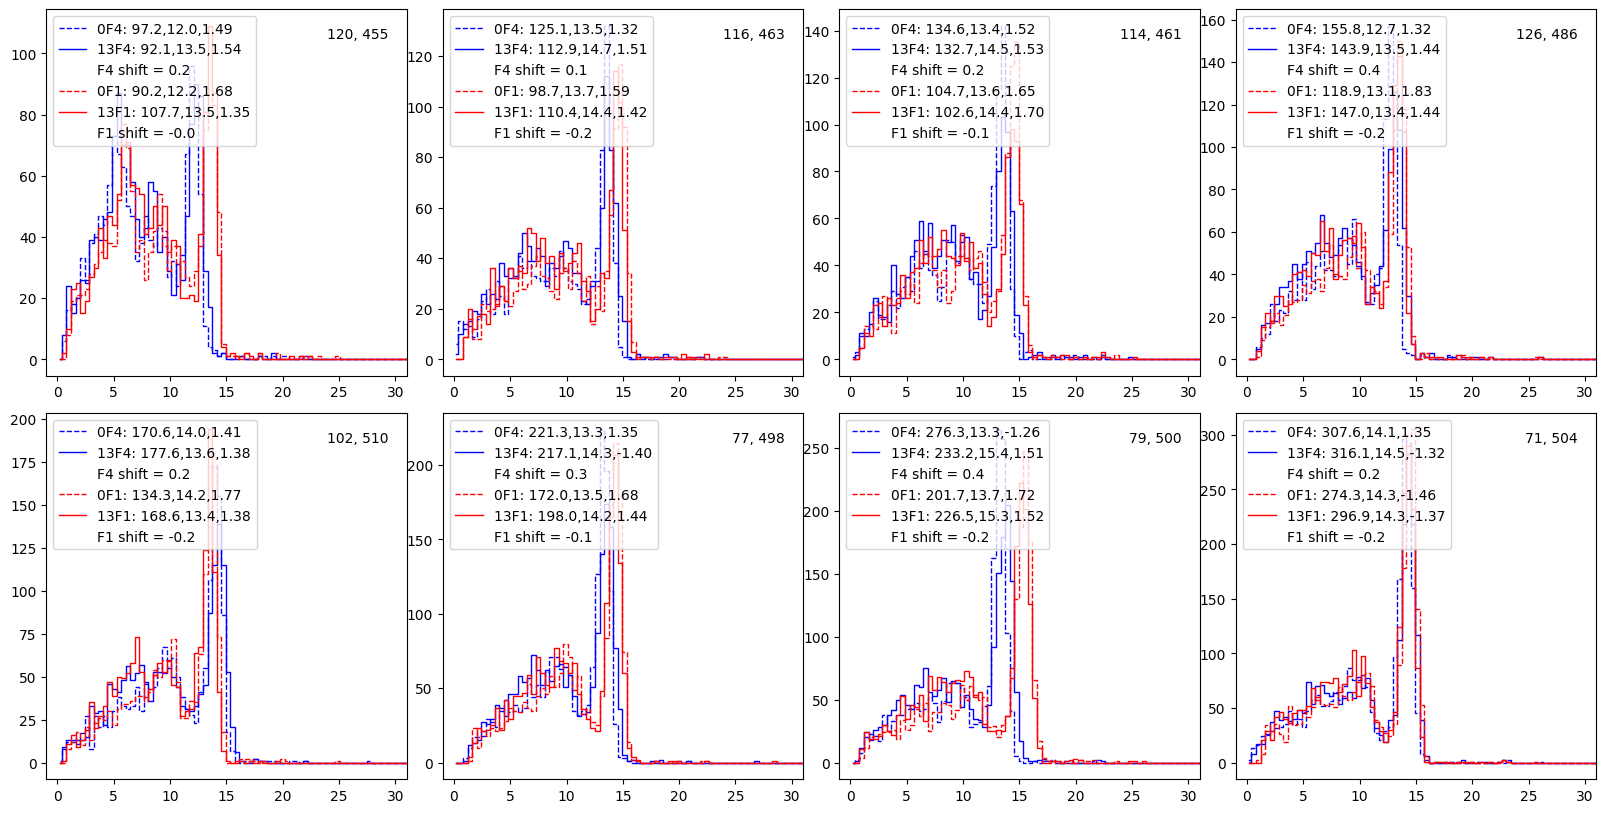

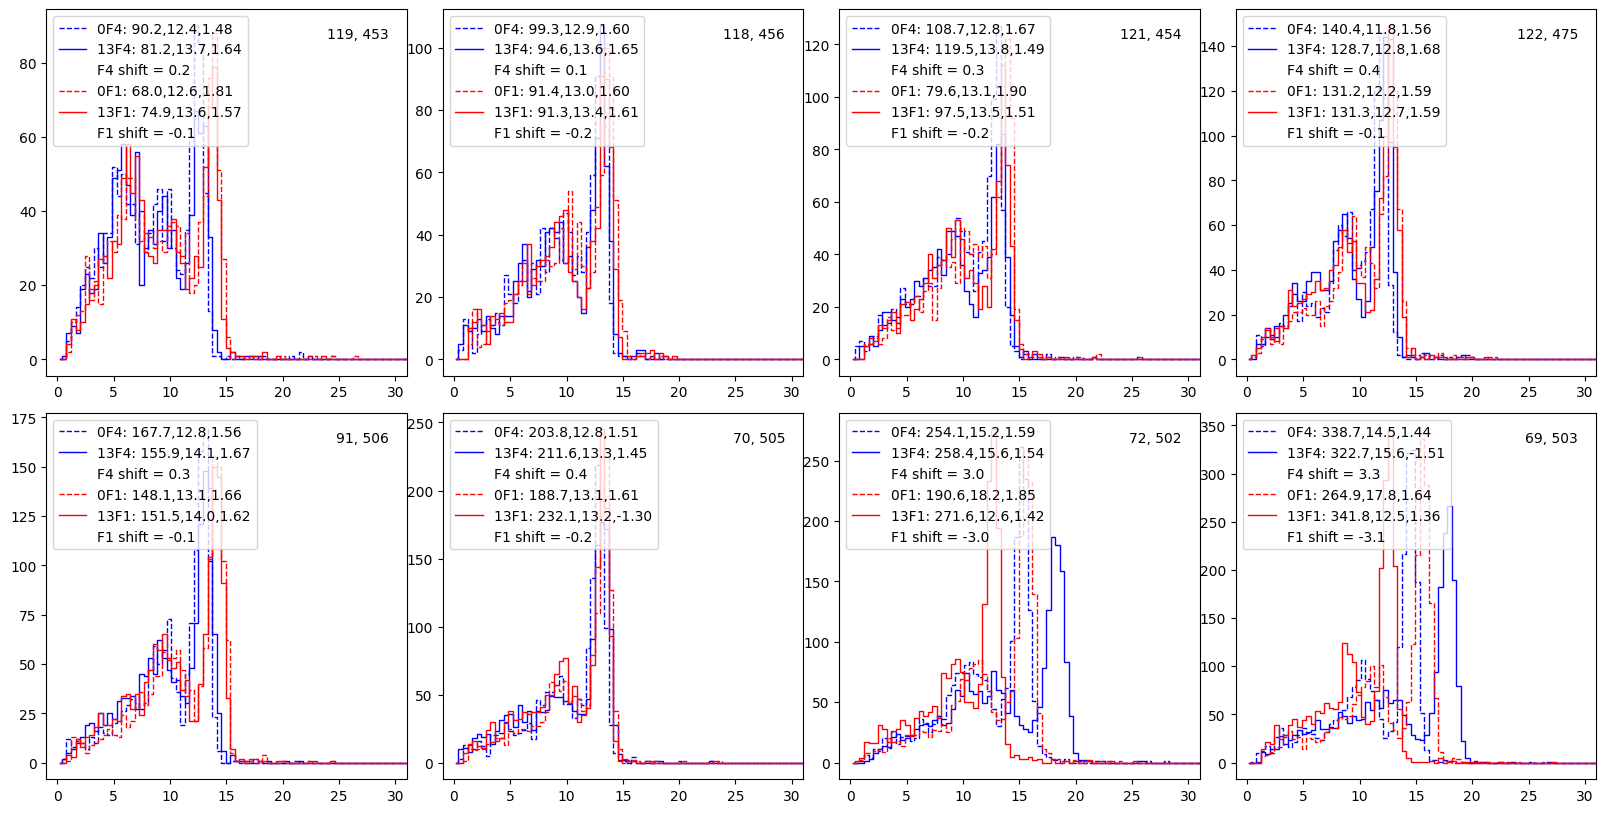

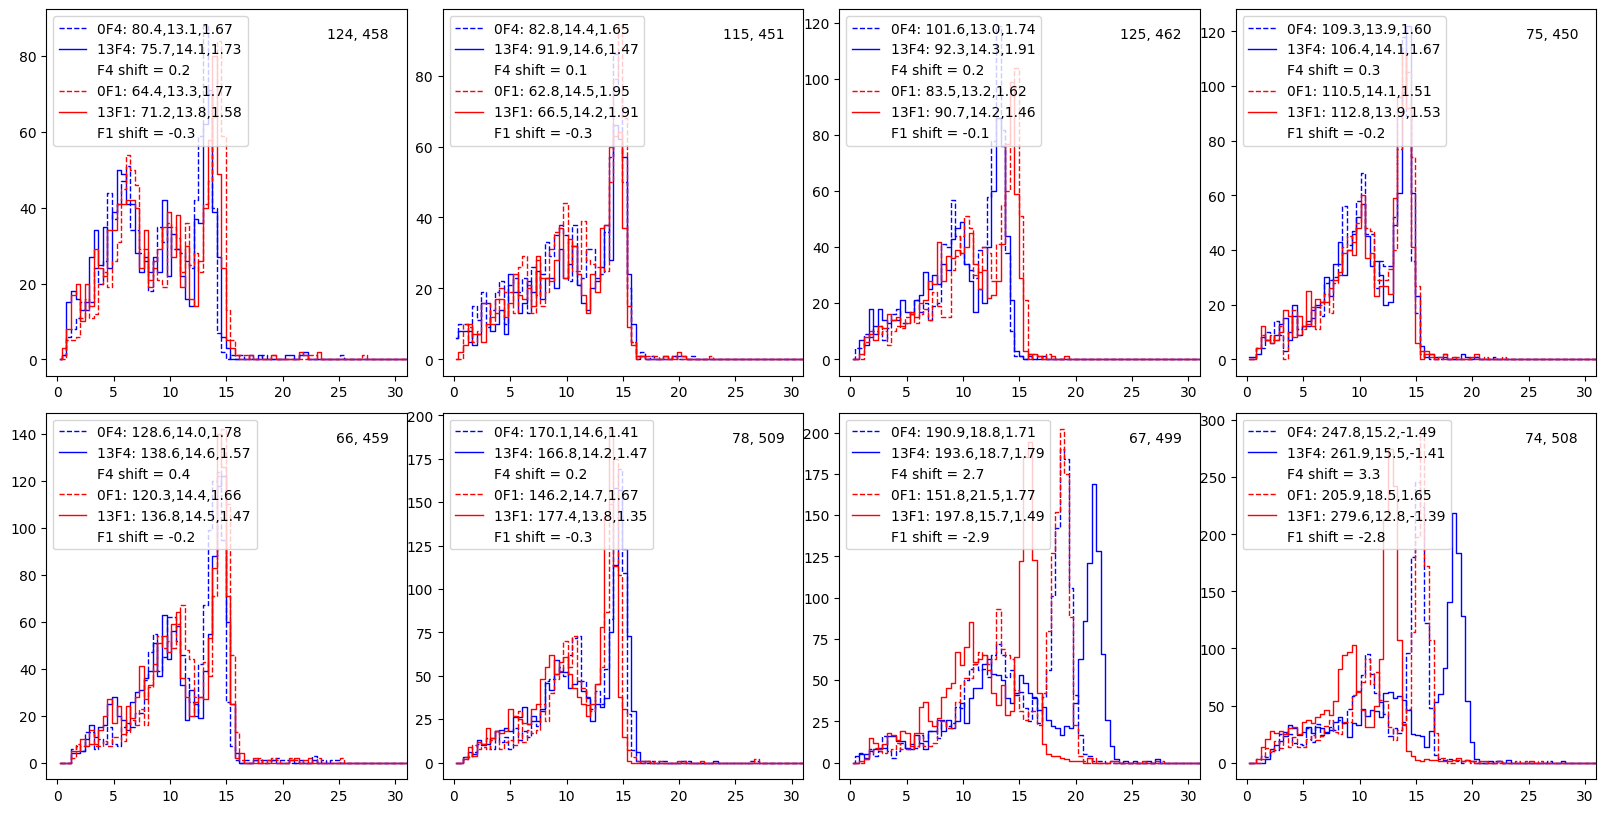

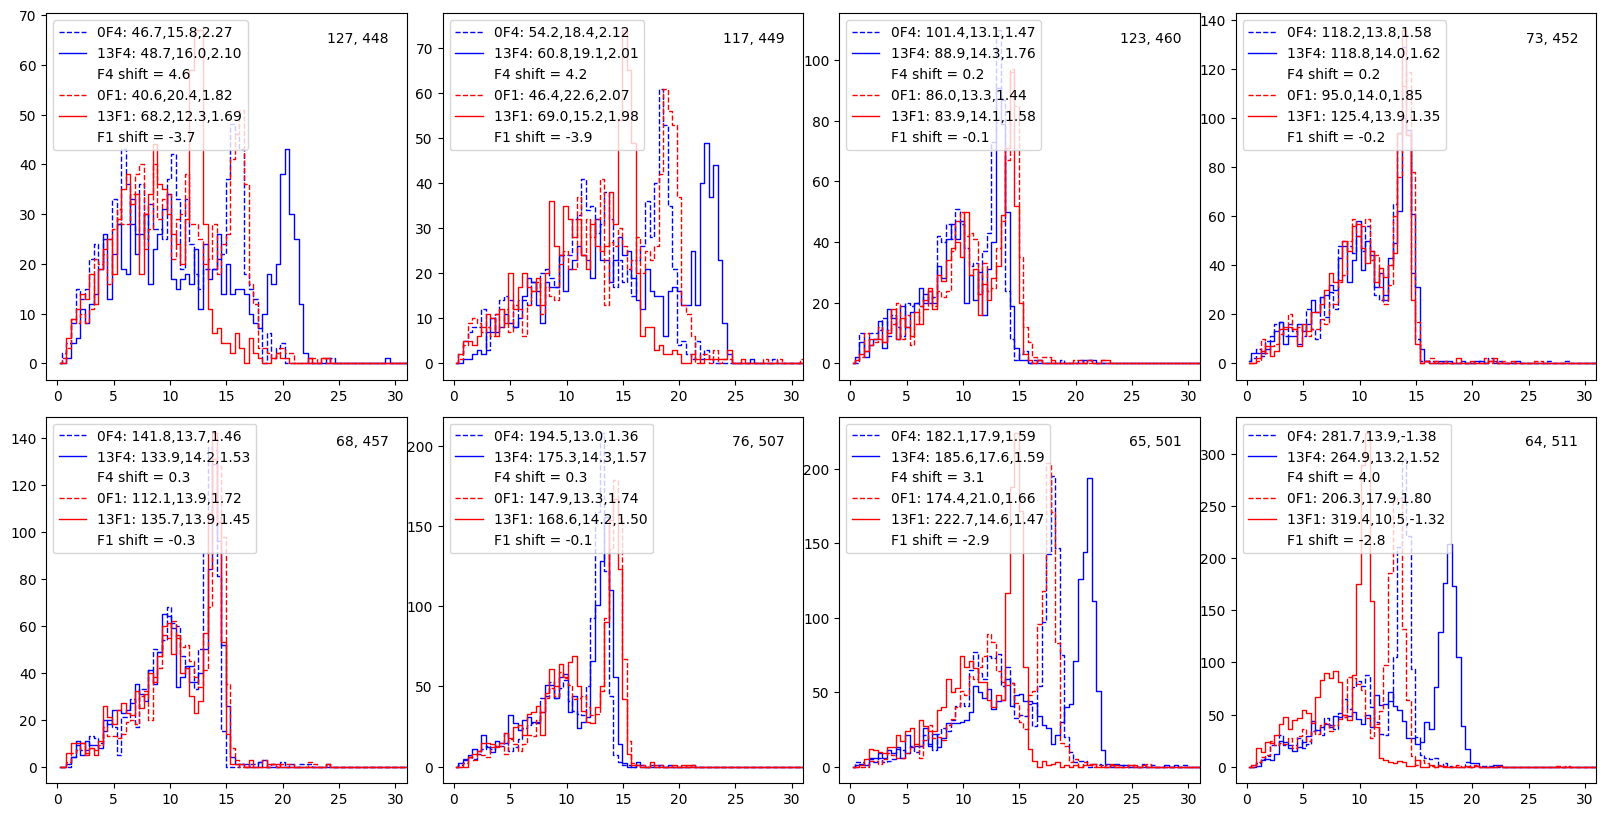

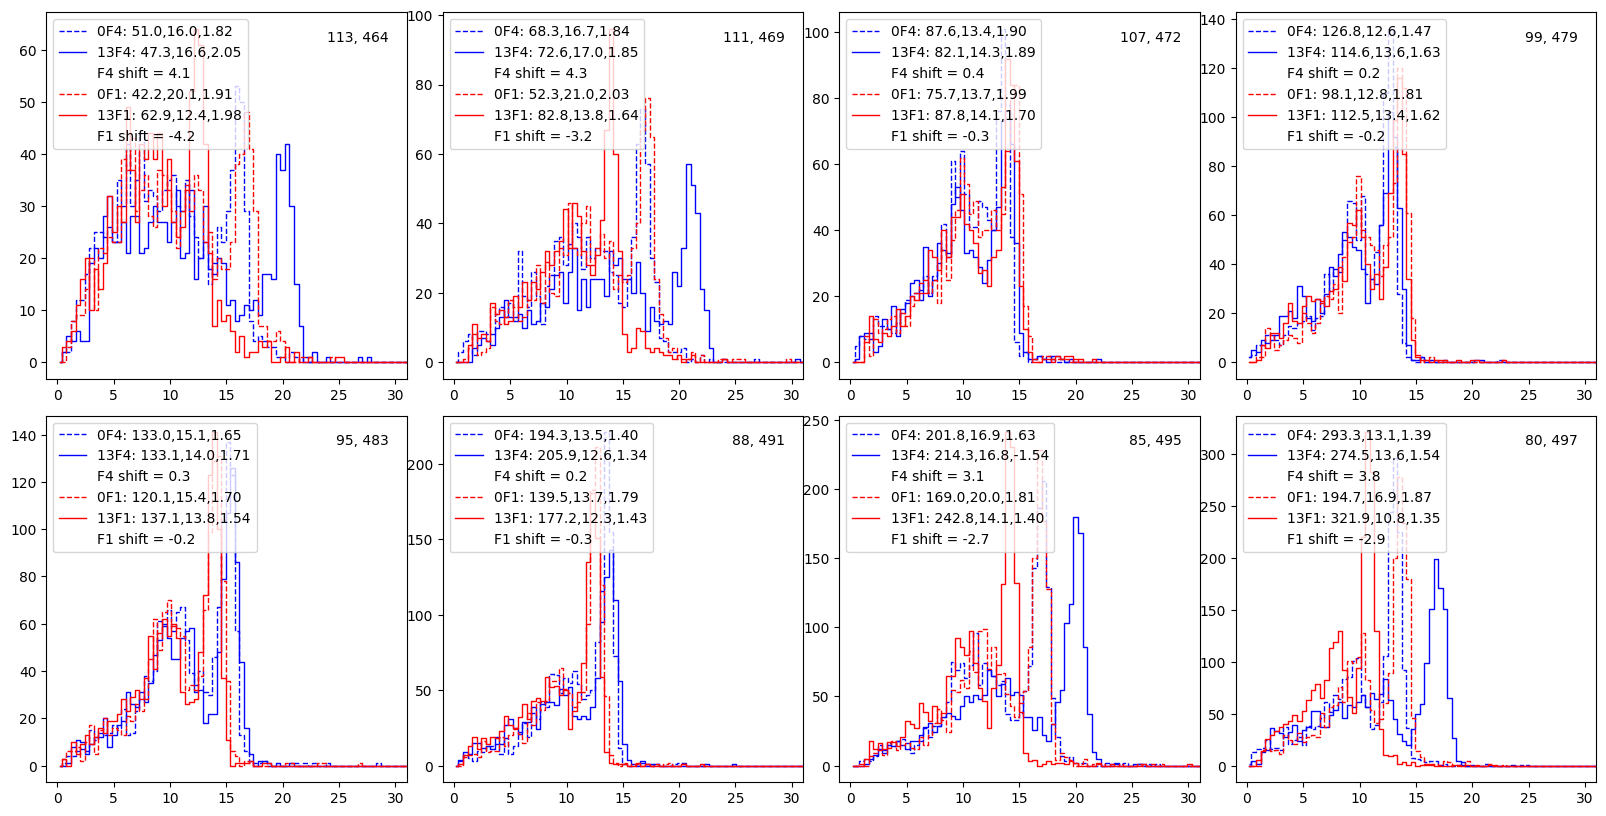

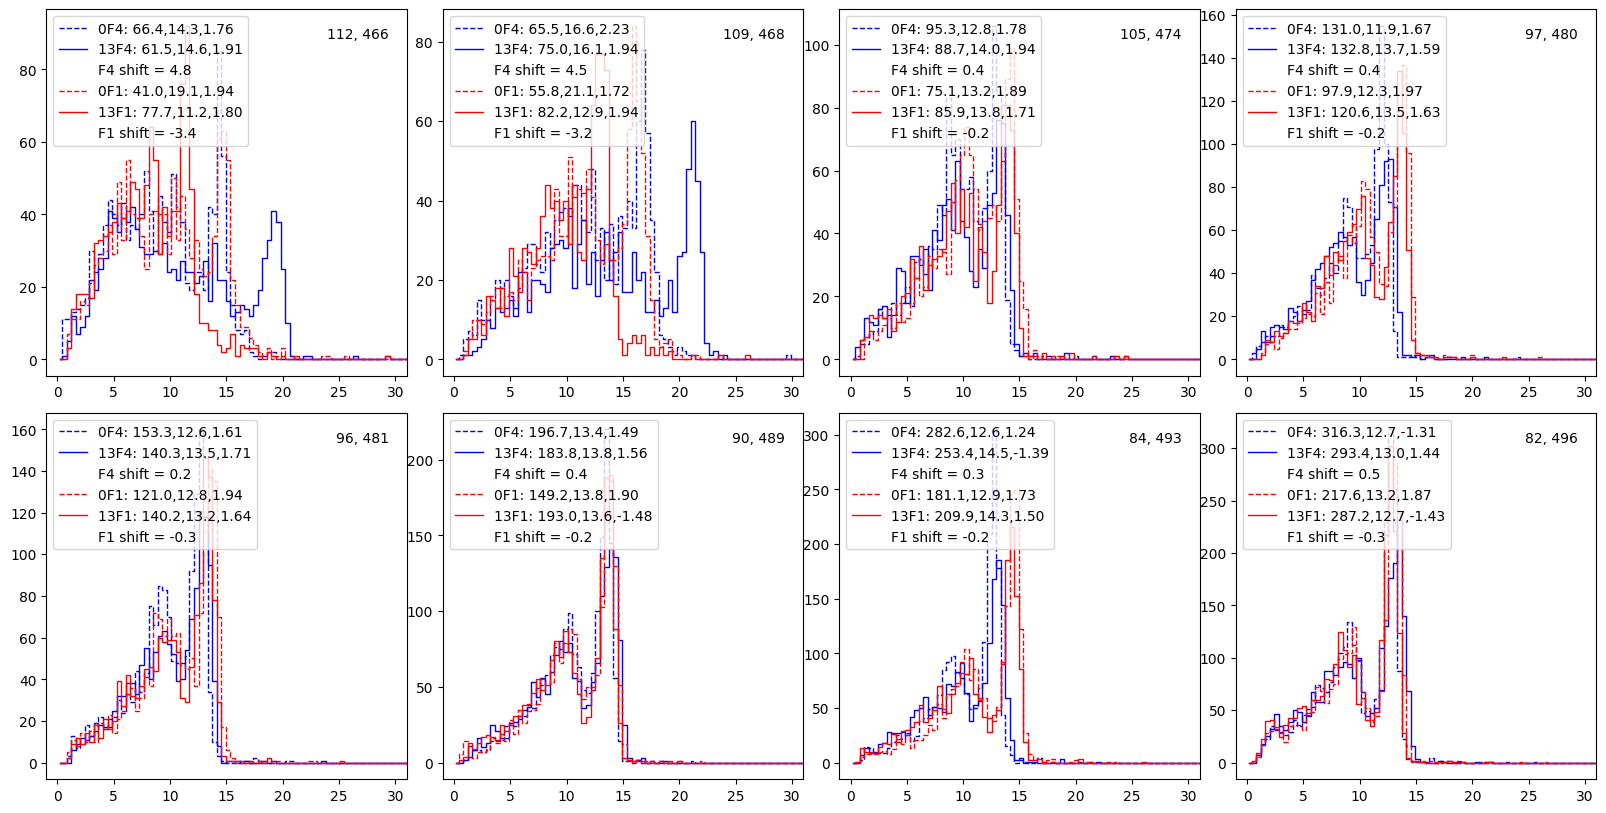

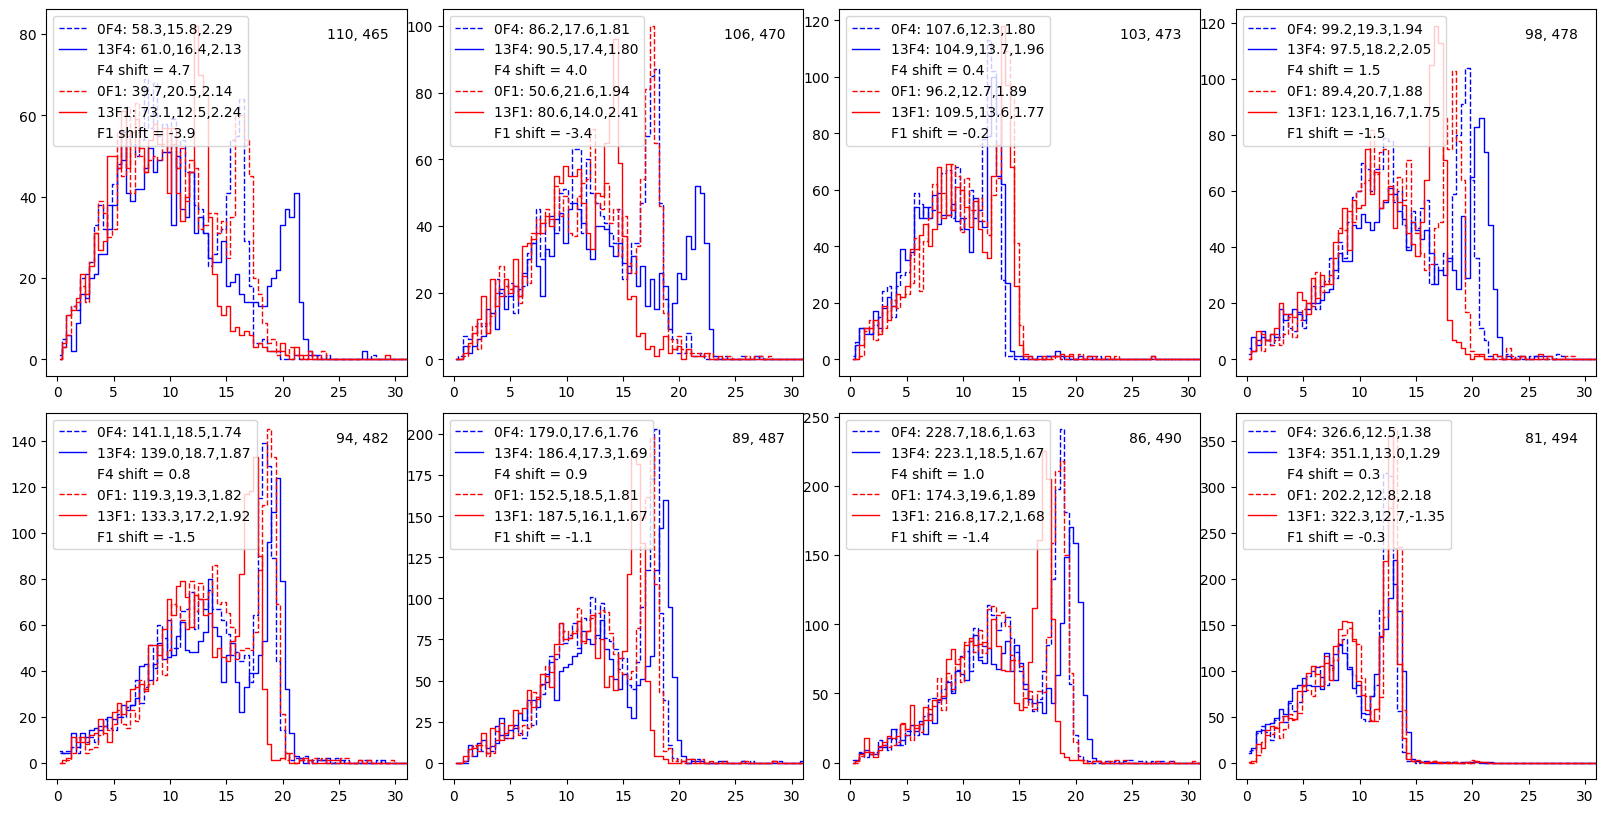

Photopeak fit failed <built-in function id>


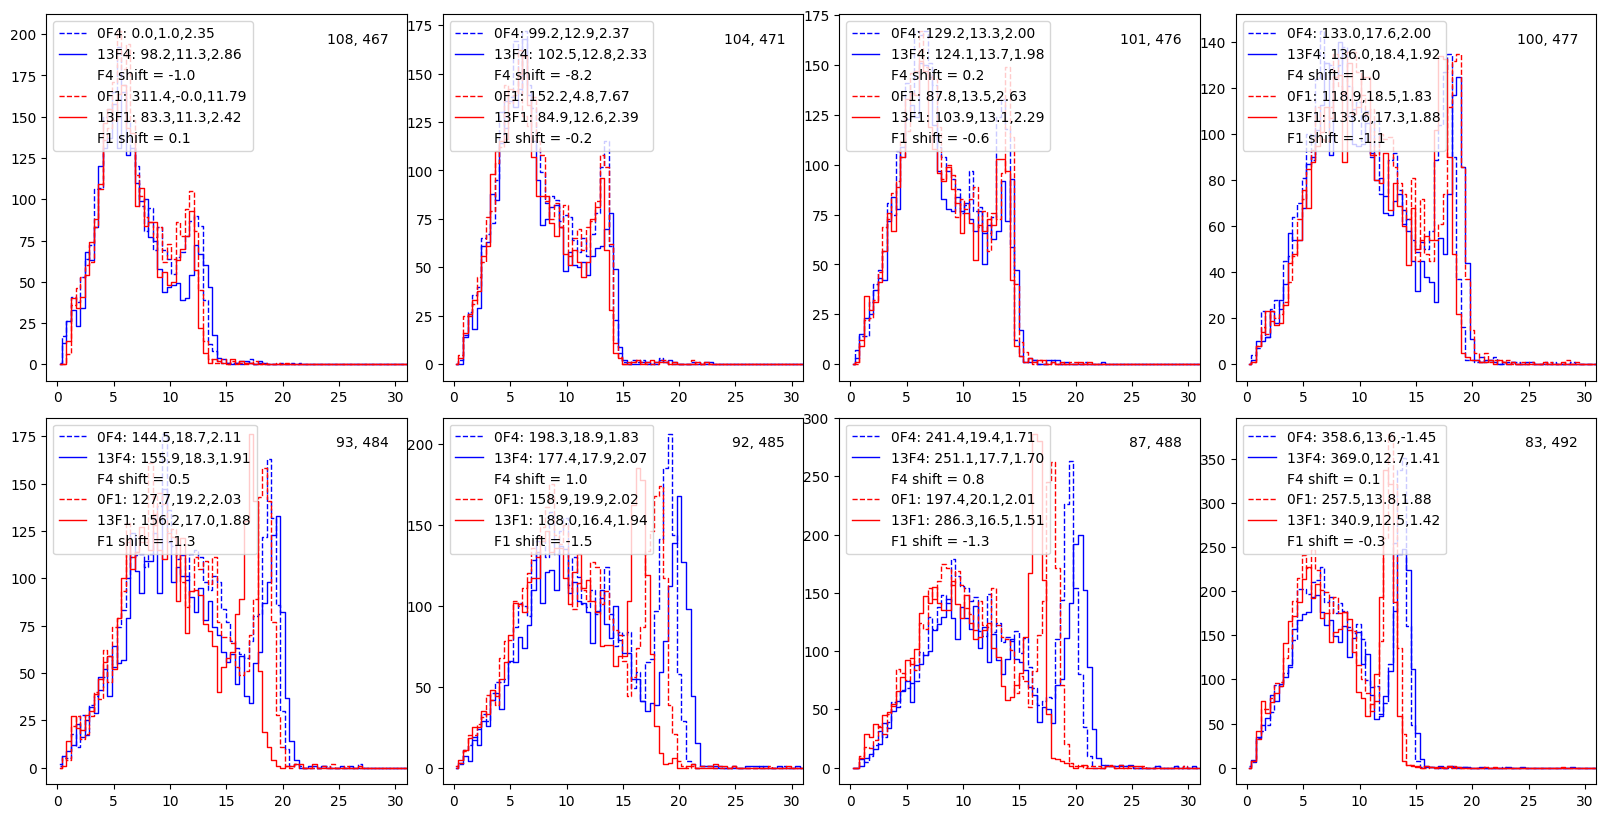

In [18]:
# Photopeaks all channels
dataindex1, dataindex2 = 0, 1
print(distances[dataindex1], distances[dataindex2])
data1 = filtered_doi_data[dataindex1]
data2 = filtered_doi_data[dataindex2]

photopeaks01 = np.zeros((8, 8), dtype=np.float32)
photopeaks02 = np.zeros((8, 8), dtype=np.float32)
photopeaks31 = np.zeros((8, 8), dtype=np.float32)
photopeaks32 = np.zeros((8, 8), dtype=np.float32)

bins = np.linspace(0, 40, 100)
bincenters = (bins[:-1] + bins[1:]) / 2
for row in range(8, 16):
    list_indices = dict(sorted(
        ((k, v) for k, v in indices.items() if v[0] == row),
        key=lambda item: item[1][1]
    ))
    list_indices = list(list_indices.keys())
    fig, subplots = plt.subplots(2, 4, figsize=(20, 10))
    subplots = subplots.flatten()
    for i in range(len(list_indices)):
        energies01 = data1[:, 4][data1[:, 5] == list_indices[i]]
        energies31 = data1[:, 2][data1[:, 3] == get_compliment(list_indices[i]) + 384]
        energies02 = data2[:, 4][data2[:, 5] == list_indices[i]]
        energies32 = data2[:, 2][data2[:, 3] == get_compliment(list_indices[i]) + 384]
        hist01, _ = np.histogram(energies01, bins=bins)
        hist31, _ = np.histogram(energies31, bins=bins)
        hist02, _ = np.histogram(energies02, bins=bins)
        hist32, _ = np.histogram(energies32, bins=bins)
        fit_p01 = findPhotopeak(hist01, bincenters)
        fit_p31 = findPhotopeak(hist31, bincenters)
        fit_p02 = findPhotopeak(hist02, bincenters)
        fit_p32 = findPhotopeak(hist32, bincenters)
        photopeaks01[row-8, i] = fit_p01[1]
        photopeaks31[row-8, i] = fit_p31[1]
        photopeaks02[row-8, i] = fit_p02[1]
        photopeaks32[row-8, i] = fit_p32[1]
        subplots[i].step(bincenters, hist01, color = 'blue', where = 'mid', label = f'{str(distances[dataindex1])}F4: {fit_p01[0]:.1f},{fit_p01[1]:.1f},{2.355*fit_p01[2]:.2f}', linewidth = 1, linestyle = '--')
        subplots[i].step(bincenters, hist02, color = 'blue', where = 'mid', label = f'{str(distances[dataindex2])}F4: {fit_p31[0]:.1f},{fit_p31[1]:.1f},{2.355*fit_p31[2]:.2f}', linewidth = 1)
        subplots[i].plot([0, 0], [0, 0], alpha = 0, label = f'F4 shift = {fit_p02[1] - fit_p01[1]:.1f}')
        subplots[i].step(bincenters, hist31, color = 'red', where = 'mid', label = f'{str(distances[dataindex1])}F1: {fit_p02[0]:.1f},{fit_p02[1]:.1f},{2.355*fit_p02[2]:.2f}', linewidth = 1, linestyle = '--')
        subplots[i].step(bincenters, hist32, color = 'red', where = 'mid', label = f'{str(distances[dataindex2])}F1: {fit_p32[0]:.1f},{fit_p32[1]:.1f},{2.355*fit_p32[2]:.2f}', linewidth = 1)
        subplots[i].plot([0, 0], [0, 0], alpha = 0, label = f'F1 shift = {fit_p32[1] - fit_p31[1]:.1f}')
        subplots[i].set_xlim(-1, 31)
        subplots[i].legend(loc = 'upper left', fontsize = 10)
        subplots[i].text(0.95, 0.95, f'{list_indices[i]}, {get_compliment(list_indices[i]) + 384}', fontsize = 10, ha = 'right', va = 'top', transform = subplots[i].transAxes)
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    plt.show()
photopeaksinit0keep.append(photopeaks01)
photopeaksinit3keep.append(photopeaks31)
photopeakshifts0keep.append(photopeaks02 - photopeaks01)
photopeakshifts3keep.append(photopeaks32 - photopeaks31)


<Figure size 640x480 with 0 Axes>

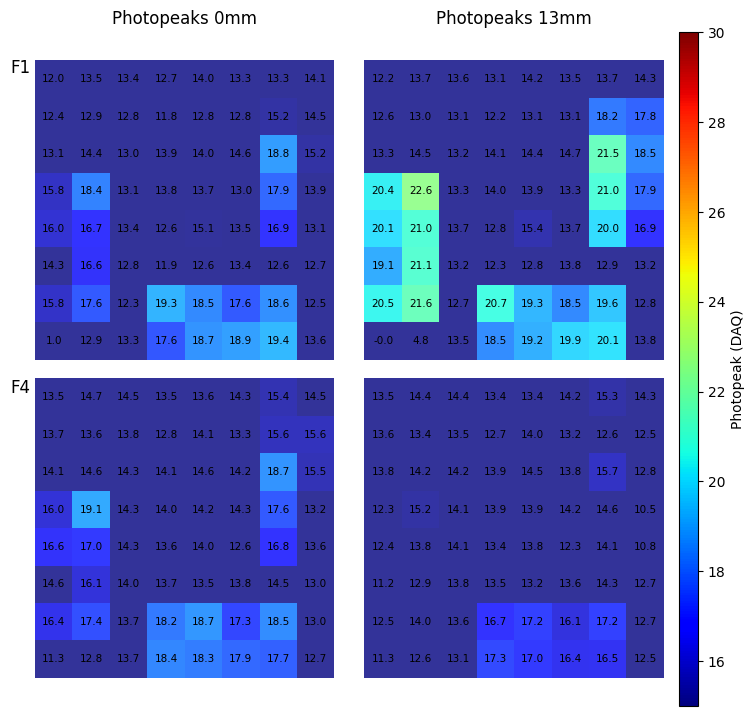

<Figure size 640x480 with 0 Axes>

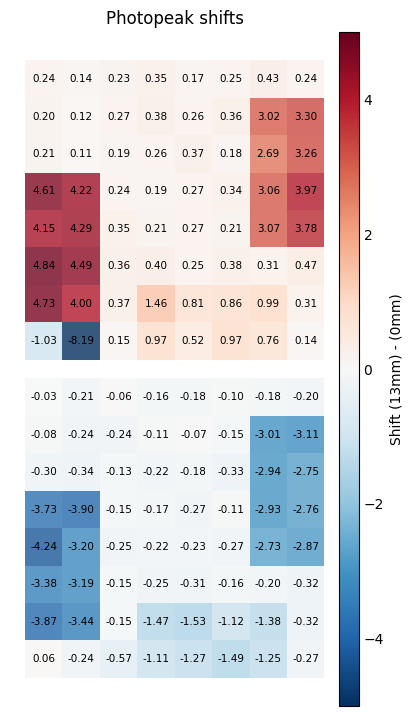

<Figure size 640x480 with 0 Axes>

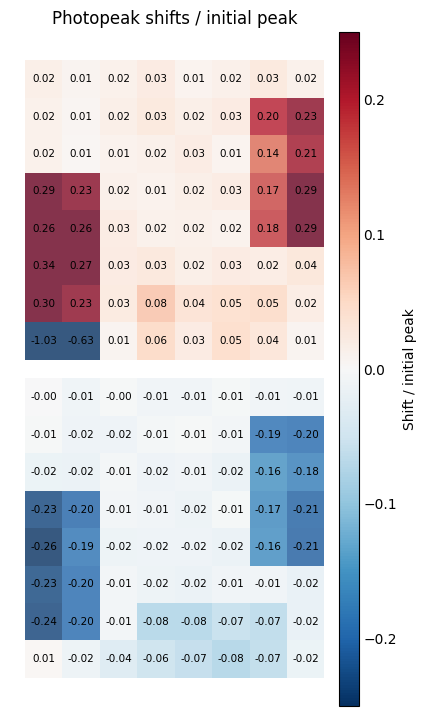

<Figure size 640x480 with 0 Axes>

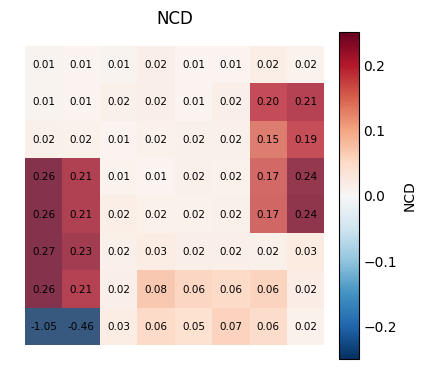

In [19]:
def getPhotopeakColor(val, min_val = 15, max_val = 30, cmap = plt.cm.jet):
    val = max(min_val + 0.0001, min(max_val - 0.0001, val))
    norm_val = (float(val) - min_val) / (max_val - min_val)
    norm_val = max(0, min(1, norm_val))
    return cmap(norm_val)

plt.figure(0)
fig, subplots = plt.subplots(1, 3, figsize=(8.75, 8.75), gridspec_kw={'width_ratios': [8.5, 8.5, 0.5]})

for n in range(64, 128):
    y, x = indices[n]
    y = 15 - y
    rect = patches.Rectangle((x, y), 1, 1, linewidth=0, facecolor=getPhotopeakColor(photopeaks01[7-y, x]), alpha=0.8)
    subplots[0].add_patch(rect)
    subplots[0].text(x + 0.5, y + 0.5, f'{photopeaks01[7-y, x]:.1f}', fontsize=7.5, ha='center', va='center')
    rect = patches.Rectangle((x, y - 8.5), 1, 1, linewidth=0, facecolor=getPhotopeakColor(photopeaks31[7-y, x]), alpha=0.8)
    subplots[0].add_patch(rect)
    subplots[0].text(x + 0.5, y - 8.5 + 0.5, f'{photopeaks31[7-y, x]:.1f}', fontsize=7.5, ha='center', va='center')
    rect = patches.Rectangle((x, y), 1, 1, linewidth=0, facecolor=getPhotopeakColor(photopeaks02[7-y, x]), alpha=0.8)
    subplots[1].add_patch(rect)
    subplots[1].text(x + 0.5, y + 0.5, f'{photopeaks02[7-y, x]:.1f}', fontsize=7.5, ha='center', va='center')
    rect = patches.Rectangle((x, y - 8.5), 1, 1, linewidth=0, facecolor=getPhotopeakColor(photopeaks32[7-y, x]), alpha=0.8)
    subplots[1].add_patch(rect)
    subplots[1].text(x + 0.5, y - 8.5 + 0.5, f'{photopeaks32[7-y, x]:.1f}', fontsize=7.5, ha='center', va='center')
for i in [0, 1]:
    subplots[i].set_xlim(-0.25, 8.25)
    subplots[i].set_ylim(-9, 8.5)
    subplots[i].axis('equal')
for i in range(3):
    subplots[i].tick_params(axis='both', which='both', bottom=False, top=False,
                left=False, right=False, labelbottom=False, labelleft=False)
    for spine in subplots[i].spines.values():
        spine.set_visible(False)
subplots[0].set_title(f'Photopeaks {str(distances[dataindex1])}mm')
subplots[0].text(0, 0.96, f'F1', fontsize=12, ha='center', va='top', transform=subplots[0].transAxes)
subplots[0].text(0, 0.485, f'F4', fontsize=12, ha='center', va='top', transform=subplots[0].transAxes)
subplots[1].set_title(f'Photopeaks {str(distances[dataindex2])}mm')
sm = ScalarMappable(cmap=plt.cm.jet, norm=plt.Normalize(vmin=15, vmax=30))
cb = plt.colorbar(sm, cax=subplots[2], orientation='vertical')
cb.set_label('Photopeak (DAQ)')
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

plt.figure(1)
fig, subplots = plt.subplots(1, 2, figsize=(4.5, 8.75), gridspec_kw={'width_ratios': [8.5, 0.5]})
photopeakshifts0 = photopeaks02 - photopeaks01
photopeakshifts3 = photopeaks32 - photopeaks31
bounds = (-5, 5)
for n in range(64, 128):
    y, x = indices[n]
    y = 15 - y
    rect = patches.Rectangle((x, y), 1, 1, linewidth=0, facecolor=getPhotopeakColor(photopeakshifts0[7-y, x], min_val = bounds[0], max_val = bounds[1], cmap = plt.cm.RdBu_r), alpha=0.8)
    subplots[0].add_patch(rect)
    subplots[0].text(x + 0.5, y + 0.5, f'{photopeakshifts0[7-y, x]:.2f}', fontsize=7.5, ha='center', va='center')
    rect = patches.Rectangle((x, y - 8.5), 1, 1, linewidth=0, facecolor=getPhotopeakColor(photopeakshifts3[7-y, x], min_val = bounds[0], max_val = bounds[1], cmap = plt.cm.RdBu_r), alpha=0.8)
    subplots[0].add_patch(rect)
    subplots[0].text(x + 0.5, y - 8.5 + 0.5, f'{photopeakshifts3[7-y, x]:.2f}', fontsize=7.5, ha='center', va='center')

subplots[0].set_xlim(-0.25, 8.25)
subplots[0].set_ylim(-9, 8.5)
subplots[0].axis('equal')
for i in range(2):
    subplots[i].tick_params(axis='both', which='both', bottom=False, top=False,
                left=False, right=False, labelbottom=False, labelleft=False)
    for spine in subplots[i].spines.values():
        spine.set_visible(False)
sm = ScalarMappable(cmap=plt.cm.RdBu_r, norm=plt.Normalize(vmin=bounds[0], vmax=bounds[1]))
cb = plt.colorbar(sm, cax=subplots[1], orientation='vertical')
cb.set_label(f'Shift ({str(distances[dataindex2])}mm) - ({str(distances[dataindex1])}mm)')
subplots[1].tick_params(axis='both', which='both', length=0)
subplots[0].set_title(f'Photopeak shifts')
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

plt.figure(2)
fig, subplots = plt.subplots(1, 2, figsize=(4.5, 8.75), gridspec_kw={'width_ratios': [8.5, 0.5]})
photopeakshiftsoverinit0 = photopeakshifts0 / photopeaks01
photopeakshiftsoverinit3 = photopeakshifts3 / photopeaks31
bounds = (-0.25, 0.25)
for n in range(64, 128):
    y, x = indices[n]
    y = 15 - y
    rect = patches.Rectangle((x, y), 1, 1, linewidth=0, facecolor=getPhotopeakColor(photopeakshiftsoverinit0[7-y, x], min_val = bounds[0], max_val = bounds[1], cmap = plt.cm.RdBu_r), alpha=0.8)
    subplots[0].add_patch(rect)
    subplots[0].text(x + 0.5, y + 0.5, f'{photopeakshiftsoverinit0[7-y, x]:.2f}', fontsize=7.5, ha='center', va='center')
    rect = patches.Rectangle((x, y - 8.5), 1, 1, linewidth=0, facecolor=getPhotopeakColor(photopeakshiftsoverinit3[7-y, x], min_val = bounds[0], max_val = bounds[1], cmap = plt.cm.RdBu_r), alpha=0.8)
    subplots[0].add_patch(rect)
    subplots[0].text(x + 0.5, y - 8.5 + 0.5, f'{photopeakshiftsoverinit3[7-y, x]:.2f}', fontsize=7.5, ha='center', va='center')

subplots[0].set_xlim(-0.25, 8.25)
subplots[0].set_ylim(-9, 8.5)
subplots[0].axis('equal')
for i in range(2):
    subplots[i].tick_params(axis='both', which='both', bottom=False, top=False,
                left=False, right=False, labelbottom=False, labelleft=False)
    for spine in subplots[i].spines.values():
        spine.set_visible(False)
sm = ScalarMappable(cmap=plt.cm.RdBu_r, norm=plt.Normalize(vmin=bounds[0], vmax=bounds[1]))
cb = plt.colorbar(sm, cax=subplots[1], orientation='vertical')
cb.set_label('Shift / initial peak')
subplots[1].tick_params(axis='both', which='both', length=0)
subplots[0].set_title(f'Photopeak shifts / initial peak')
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

plt.figure(3)
pedestal = 0
fig, subplots = plt.subplots(1, 2, figsize=(4.5, 4.25), gridspec_kw={'width_ratios': [8.5, 0.5]})
photopeaks02n = (photopeaks02 - pedestal) / (photopeaks01 - pedestal)
photopeaks32n = (photopeaks32 - pedestal) / (photopeaks31 - pedestal)
bounds = (-0.25, 0.25)
ncds = (photopeaks02n - photopeaks32n) / (photopeaks02n + photopeaks32n)
#ncds = (photopeaks02 - photopeaks32) / (photopeaks02 + photopeaks32)
for n in range(64, 128):
    y, x = indices[n]
    y = 15 - y
    rect = patches.Rectangle((x, y), 1, 1, linewidth=0, facecolor=getPhotopeakColor(ncds[7-y, x], min_val = bounds[0], max_val = bounds[1], cmap = plt.cm.RdBu_r), alpha=0.8)
    subplots[0].add_patch(rect)
    subplots[0].text(x + 0.5, y + 0.5, f'{ncds[7-y, x]:.2f}', fontsize=7.5, ha='center', va='center')
subplots[0].set_xlim(-0.25, 8.25)
subplots[0].set_ylim(-0.25, 8.25)
subplots[0].axis('equal')
for i in range(2):
    subplots[i].tick_params(axis='both', which='both', bottom=False, top=False,
                left=False, right=False, labelbottom=False, labelleft=False)
    for spine in subplots[i].spines.values():
        spine.set_visible(False)
sm = ScalarMappable(cmap=plt.cm.RdBu_r, norm=plt.Normalize(vmin=bounds[0], vmax=bounds[1]))
cb = plt.colorbar(sm, cax=subplots[1], orientation='vertical')
cb.set_label('NCD')
subplots[1].tick_params(axis='both', which='both', length=0)
subplots[0].set_title(f'NCD')
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

[469. 504. 470. 507. 472.]
731
[30.03121438 23.44791322  0.9603224 ]


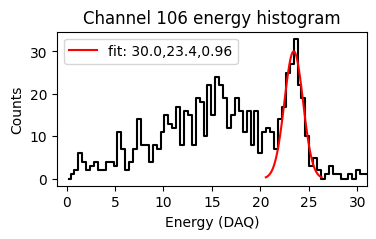

In [217]:
refid = 106
dataindex = 0
data = filtered_doi_data[dataindex]
print(data[0:5,3])
energies = data[:, 4][data[:, 5] % 128 == refid]
print(len(energies))
bins = np.linspace(0, 40, 100)
bincenters = (bins[:-1] + bins[1:]) / 2
hist, _ = np.histogram(energies, bins=bins)
fit_p = findPhotopeak(hist, bincenters)
print(fit_p)
plt.figure(4, figsize = (4, 2))
plt.step(bincenters, hist, color = 'black', where = 'mid')
plottingbounds = [fit_p[1] - 3*fit_p[2], fit_p[1] + 3*fit_p[2]]
plt.plot(np.linspace(plottingbounds[0], plottingbounds[1], 100), gaussian(np.linspace(plottingbounds[0], plottingbounds[1], 100), *fit_p), color = 'red', label = f'fit: {fit_p[0]:.1f},{fit_p[1]:.1f},{fit_p[2]:.2f}')
plt.xlim(-1, 31)
plt.xlabel('Energy (DAQ)')
plt.ylabel('Counts')
plt.title(f'Channel {refid} energy histogram')
plt.legend(loc = 'upper left')
plt.show()

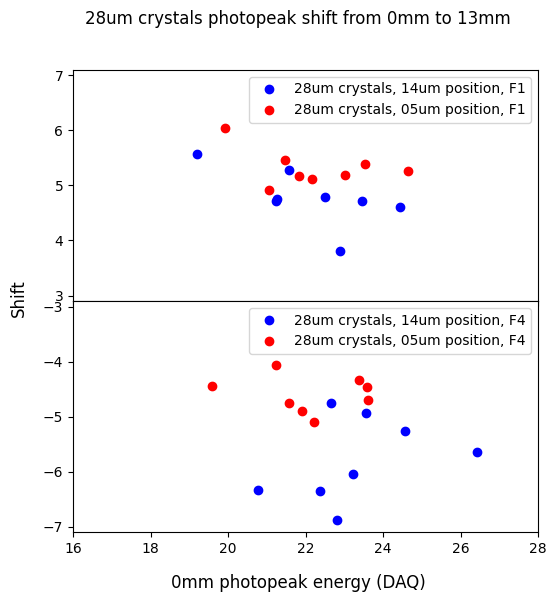

In [298]:
cname = '28um'
s1 = (1, 5, 6, 8)
s1 = (3,7, 0,2)
inits01 = photopeaksinit0keep[1][s1[0]:s1[1], s1[2]:s1[3]]
shifts01 = photopeakshifts0keep[1][s1[0]:s1[1], s1[2]:s1[3]]
inits31 = photopeaksinit3keep[1][s1[0]:s1[1], s1[2]:s1[3]]
shifts31 = photopeakshifts3keep[1][s1[0]:s1[1], s1[2]:s1[3]]
s2 = (0, 2, 1, 5)
s2 = (6,8, 3, 7)
inits02 = photopeaksinit0keep[2][s2[0]:s2[1], s2[2]:s2[3]]
shifts02 = photopeakshifts0keep[2][s2[0]:s2[1], s2[2]:s2[3]]
inits32 = photopeaksinit3keep[2][s2[0]:s2[1], s2[2]:s2[3]]
shifts32 = photopeakshifts3keep[2][s2[0]:s2[1], s2[2]:s2[3]]
fig, subplots = plt.subplots(2, 1, figsize = (6, 6), sharex = True)
subplots[0].plot(inits01.flatten(), shifts01.flatten(), 'o', color = 'blue', label = f'{cname} crystals, 14um position, F1')
subplots[0].plot(inits02.flatten(), shifts02.flatten(), 'o', color = 'red', label = f'{cname} crystals, 05um position, F1')
subplots[0].legend(fontsize = 10)
subplots[1].plot(inits31.flatten(), shifts31.flatten(), 'o', color = 'blue', label = f'{cname} crystals, 14um position, F4')
subplots[1].plot(inits32.flatten(), shifts32.flatten(), 'o', color = 'red', label = f'{cname} crystals, 05um position, F4')
subplots[1].legend(fontsize = 10)
subplots[0].set_xlim(16, 28)
subplots[0].set_ylim(2.9, 7.1)
subplots[1].set_ylim(-7.1, -2.9)
fig.suptitle(f'{cname} crystals photopeak shift from 0mm to 13mm')
fig.supxlabel('0mm photopeak energy (DAQ)')
fig.supylabel('Shift')
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()